In [2]:
from pathlib import Path

import numpy as np 
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
old_ais_path = "../probabilistic_projections/global/gmslr_projections.nc"
new_ais_path = "../probabilistic_projections/global/gmslr_projections_NEW_AIS_RATE.nc"
c_new_ais_path = "../probabilistic_projections/global/gmslr_projections_NEW_AIS.nc"
old_ds = xr.open_dataset(old_ais_path)
new_ds = xr.open_dataset(new_ais_path)
c_new_ds = xr.open_dataset(c_new_ais_path)

Timeseries

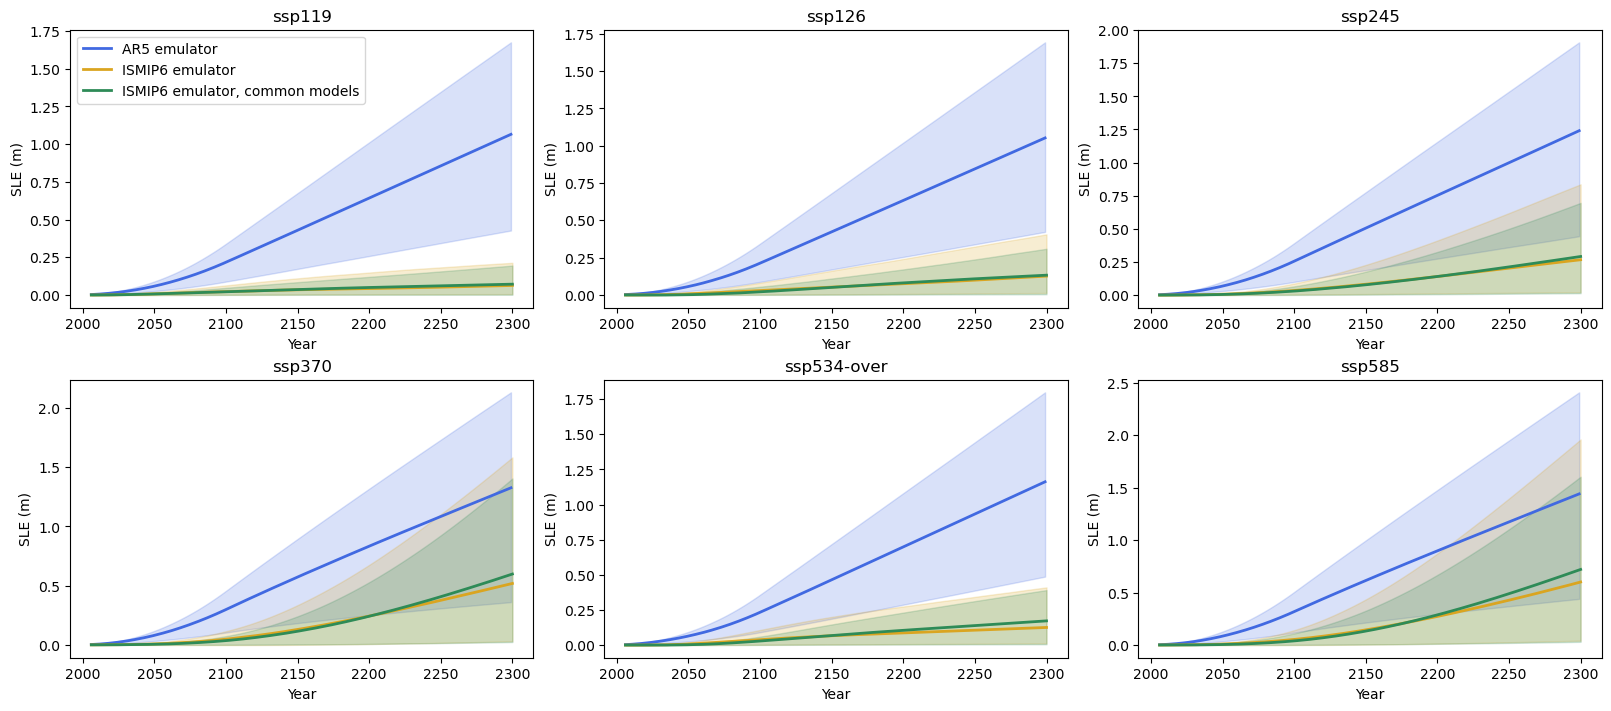

In [4]:
fig = plt.figure(figsize=(16, 7), layout="constrained")

for scen_idx, scenario in enumerate(old_ds.scenario):
    ax = fig.add_subplot(2, 3, scen_idx+1)
    # Median
    ax.set_title(f"{scenario.values}")
    ax.plot(old_ds.year, old_ds.antarctica[scen_idx, 2], color="royalblue", lw=2, label="AR5 emulator")
    ax.plot(new_ds.year, new_ds.antarctica[scen_idx, 2], color="goldenrod", lw=2, label="ISMIP6 emulator")
    ax.plot(c_new_ds.year, c_new_ds.antarctica[scen_idx, 2], color="seagreen", lw=2, label="ISMIP6 emulator, common models")
    ax.fill_between(old_ds.year, old_ds.antarctica[scen_idx, 1], old_ds.antarctica[scen_idx, 3], color="royalblue", alpha=0.2)
    ax.fill_between(new_ds.year, new_ds.antarctica[scen_idx, 1], new_ds.antarctica[scen_idx, 3], color="goldenrod", alpha=0.2)
    ax.fill_between(c_new_ds.year, c_new_ds.antarctica[scen_idx, 1], c_new_ds.antarctica[scen_idx, 3], color="seagreen", alpha=0.2)
    ax.set_ylabel("SLE (m)")
    ax.set_xlabel("Year")
    if scen_idx == 0:
        ax.legend(loc="upper left")


    

End-of-century box and whisker

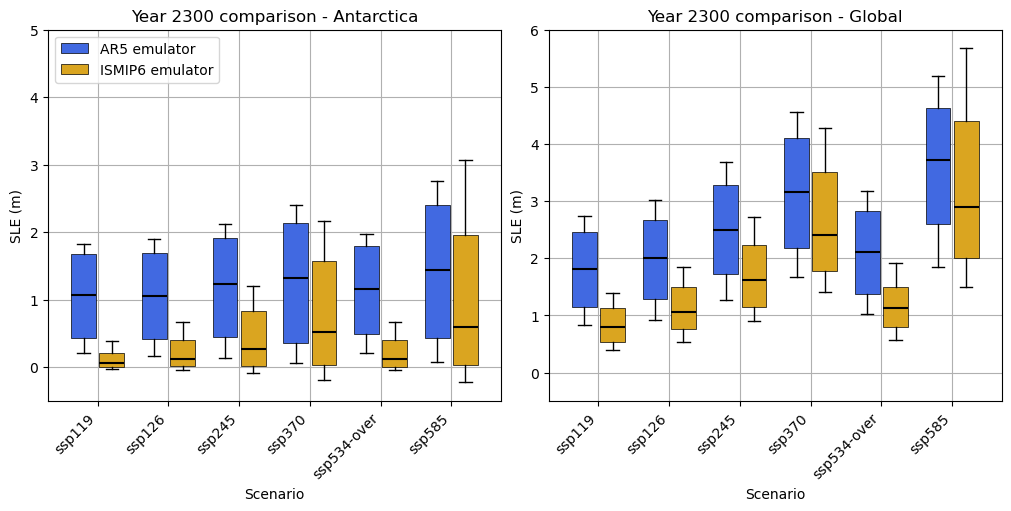

In [8]:
medianprops = dict(linestyle='-', linewidth=1.5, color='k')
boxprops = dict(linestyle='-', linewidth=0.5)

fig = plt.figure(figsize=(10, 5), layout="constrained")

# Antarctica
ax = fig.add_subplot(121)
old_eoc = []
new_eoc = []
for scen_idx, scenario in enumerate(old_ds.scenario):
    old_eoc.append(old_ds.isel(scenario=scen_idx, year=-1).antarctica.values)
    new_eoc.append(new_ds.isel(scenario=scen_idx, year=-1).antarctica.values)

indices = np.arange(1, len(old_ds.scenario)+1)
width = 0.35

old_bplot = ax.boxplot(old_eoc, positions=indices - 0.2, widths=width, patch_artist=True, medianprops=medianprops, boxprops=boxprops, label="AR5 emulator")
new_bplot = ax.boxplot(new_eoc, positions=indices + 0.2, widths=width, patch_artist=True, medianprops=medianprops, boxprops=boxprops, label="ISMIP6 emulator")

for patch, color in zip(old_bplot['boxes'], ['royalblue' for i in range(len(old_eoc))]):
    patch.set_facecolor(color)
for patch, color in zip(new_bplot['boxes'], ['goldenrod' for i in range(len(old_eoc))]):
    patch.set_facecolor(color)

ax.set_title("Year 2300 comparison - Antarctica")
ax.set_ylabel("SLE (m)")
ax.set_xlabel("Scenario")
ax.set_ylim([-0.5, 5])
ax.set_xticks(indices)
ax.set_xticklabels(old_ds.scenario.values, rotation=45, ha='right')
ax.grid()
ax.legend(loc="upper left")

# Global
ax = fig.add_subplot(122)
old_eoc = []
new_eoc = []
for scen_idx, scenario in enumerate(old_ds.scenario):
    old_eoc.append(old_ds.isel(scenario=scen_idx, year=-1).gmslr.values)
    new_eoc.append(new_ds.isel(scenario=scen_idx, year=-1).gmslr.values)

indices = np.arange(1, len(old_ds.scenario)+1)
width = 0.35

old_bplot = ax.boxplot(old_eoc, positions=indices - 0.2, widths=width, patch_artist=True, medianprops=medianprops, boxprops=boxprops, label="AR5 emulator")
new_bplot = ax.boxplot(new_eoc, positions=indices + 0.2, widths=width, patch_artist=True, medianprops=medianprops, boxprops=boxprops, label="ISMIP6 emulator")

for patch, color in zip(old_bplot['boxes'], ['royalblue' for i in range(len(old_eoc))]):
    patch.set_facecolor(color)
for patch, color in zip(new_bplot['boxes'], ['goldenrod' for i in range(len(old_eoc))]):
    patch.set_facecolor(color)

ax.set_title("Year 2300 comparison - Global")
ax.set_ylabel("SLE (m)")
ax.set_xlabel("Scenario")
ax.set_ylim([-0.5, 6])
ax.set_xticks(indices)
ax.set_xticklabels(old_ds.scenario.values, rotation=45, ha='right')
ax.grid()
plt.show()
ax.grid()
plt.show()